In [32]:
import glob
import os
import requests
import json
import time


#set current working directory
os.chdir('/home/jovyan')

#list files in shared folder
files = glob.glob("/shared_space/Galveston_Bay/*")
files

['/shared_space/Galveston_Bay/all_basin_data_subset.csv',
 '/shared_space/Galveston_Bay/RMD_Combined_Field.csv',
 '/shared_space/Galveston_Bay/TST_Monitoring_Data_May2025_for_HGAC_Website.xlsx',
 '/shared_space/Galveston_Bay/SWQM_Stations.csv',
 '/shared_space/Galveston_Bay/resultphyschem.csv']

### log into earthdata

In [41]:
#directory we are working in  
destDir = os.getcwd()

#location for new files
dest_fp = "/shared_space/Galveston_Bay/MODIS_files"

In [43]:
print("Exists?", os.path.exists(dest_fp))
print("Is directory?", os.path.isdir(dest_fp))

Exists? True
Is directory? True


In [34]:

#api link
API = "https://appeears.earthdatacloud.nasa.gov/api/"

#Earthdata Login credentials
username = 'mrfalk'
password = 'dataPlease12471!'

#token that is needed to get data
login_response = requests.post(
    f"{API}login",
    auth=(username, password)
)

if login_response.status_code != 200:
    raise Exception(f"Login failed: {login_response.text}")

token = login_response.json()['token']
headers = {
    "Content-Type": "application/json",
    "Authorization": f"Bearer {token}"
}

### explore available data

In [30]:
#this explores products available 
# request all products in the product service
product_response = requests.get('{}product'.format(API)).json()

# Create a dictionary indexed by product name & version           
products = {p['ProductAndVersion']: p for p in product_response}

#I think this is the product we will use for temperature 
product_name = 'MYD11A1.061'
products[product_name]  #this has measurements everyday, there is also a version with measurement ecery 8 days

{'Product': 'MYD11A1',
 'Platform': 'Aqua MODIS',
 'Description': 'Land Surface Temperature & Emissivity (LST&E)',
 'RasterType': 'Tile',
 'Resolution': '1000m',
 'TemporalGranularity': 'Daily',
 'Version': '061',
 'Available': True,
 'DocLink': 'https://doi.org/10.5067/MODIS/MYD11A1.061',
 'Source': 'LP DAAC',
 'TemporalExtentStart': '2002-07-04',
 'TemporalExtentEnd': 'Present',
 'Deleted': False,
 'DOI': '10.5067/MODIS/MYD11A1.061',
 'Info': {'provider_id': 'lp_prod'},
 'ProductAndVersion': 'MYD11A1.061'}

In [31]:
# Request layers for the 2nd product (index 1) in the list: MOD11A1.061
lst_response = requests.get('{}product/{}'.format(API,product_name)).json()
#shows available bands 
list(lst_response.keys()) 

['Clear_day_cov',
 'Clear_night_cov',
 'Day_view_angl',
 'Day_view_time',
 'Emis_31',
 'Emis_32',
 'LST_Day_1km',
 'LST_Night_1km',
 'Night_view_angl',
 'Night_view_time',
 'QC_Day',
 'QC_Night']

### set up task

In [32]:
#Define bounding box as GeoJSON FeatureCollection
#chose bounding box based a frame that only required one block of earthdata
#this bounding box may not be the entire region that we want (it doesn't go very far north)
geo = {
    "type": "FeatureCollection",
    "features": [
        {
            "type": "Feature",
            "geometry": {
                "type": "Polygon",
                "coordinates": [[
                    [-96.0, 28.5],
                    [-96.0, 30.0],
                    [-94.0, 30.0],
                    [-94.0, 28.5],
                    [-96.0, 28.5]
                ]]
            },
            "properties": {
                "name": "bbox_area"
            }
        }
    ]
}


In [33]:
#Define the HLS layer and product you want 
#layer comes from the lst_response

#here chose the emissivity bands for temperature
layers = [
        {'layer': 'Emis_31', 'product': product_name}, 
    {'layer': 'Emis_32', 'product':product_name}]



In [34]:
#Create the task the specifics what area to pull
task = {
    "task_type": "area",
    "task_name": "galveson_temp_try1",
    "params": {
        "dates": [
            {
                "startDate": "05-01-2017",
                "endDate": "08-31-2017"
            }
        ],
        "layers": layers,
        "output": {
            "format": {"type": "geotiff"},
            "projection": "geographic"
        },
        "geo": geo
    }
}

The below code only needs to be run once- if unsure if the data downloaded, check https://appeears.earthdatacloud.nasa.gov/explore. This is where the requests are stored

In [ ]:
# #Submit the task
# submit_response = requests.post(f"{API}task", headers=headers, json=task)

# if submit_response.status_code != 202:
#     raise Exception(f"Task submission failed: {submit_response.text}")

# task_id = submit_response.json()['task_id']
# print(f"Task submitted. ID: {task_id}")

# # Check task status until it's done
# while True:
#     status_response = requests.get(f"{API}task/{task_id}", headers=headers)
#     status_json = status_response.json()
#     status = status_json['status']
#     print(f"Task status: {status}")
#     if status in ['done', 'failed']:
#         break
#     time.sleep(30)  # Wait 30 seconds between checks

# if status == 'failed':
#     raise Exception("Task failed.")


The below code pulls the above task from the appears website and puts in a bundle (will need task id from the above code or from the website). Once it all runs once and you double check that it in the folder you want, do not run it again for it will duplicate files

In [44]:
task_id = 'b125d3e7-8bd8-4cd5-8570-9ce04f103f0b'

In [45]:
# # Call API and return bundle contents for the task_id as json
bundle = requests.get('{}bundle/{}'.format(API,task_id), headers=headers).json()  
#bundle

In [46]:
# build mapping once (your existing code) 
files = {f['file_id']: f['file_name'] for f in bundle['files']}

the code chunk below runs for a long time if you have a lot files. It will take the list of files and upload each one to the place you want it

In [47]:
for file_id, remote_name in files.items():
    url = f"{API}bundle/{task_id}/{file_id}"
    resp = requests.get(url, headers=headers, stream=True, allow_redirects=True, timeout=60)
    try:
        resp.raise_for_status()
    except Exception as e:
        print(f"Download failed for {remote_name}: {e}")
        continue

    # choose final filename (adjust logic if your names are nested)
    if remote_name.endswith('.tif'):
        filename = os.path.basename(remote_name)  # safer than split('/')[1]
    else:
        filename = remote_name

    filepath = os.path.join(dest_fp, filename)
    
    # write to disk in chunks
    with open(filepath, 'wb') as out_fh:
        for chunk in resp.iter_content(chunk_size=8192):
            if chunk:
                out_fh.write(chunk)

    print(f"Downloaded: {filepath}")

Downloaded: /shared_space/Galveston_Bay/MODIS_files/MYD11A1.061_Emis_31_doy2020003000000_aid0001.tif
Downloaded: /shared_space/Galveston_Bay/MODIS_files/MYD11A1.061_Emis_31_doy2020004000000_aid0001.tif
Downloaded: /shared_space/Galveston_Bay/MODIS_files/MYD11A1.061_Emis_31_doy2020005000000_aid0001.tif
Downloaded: /shared_space/Galveston_Bay/MODIS_files/MYD11A1.061_Emis_31_doy2020006000000_aid0001.tif
Downloaded: /shared_space/Galveston_Bay/MODIS_files/MYD11A1.061_Emis_31_doy2020007000000_aid0001.tif
Downloaded: /shared_space/Galveston_Bay/MODIS_files/MYD11A1.061_Emis_31_doy2020008000000_aid0001.tif
Downloaded: /shared_space/Galveston_Bay/MODIS_files/MYD11A1.061_Emis_31_doy2020011000000_aid0001.tif
Downloaded: /shared_space/Galveston_Bay/MODIS_files/MYD11A1.061_Emis_31_doy2020012000000_aid0001.tif
Downloaded: /shared_space/Galveston_Bay/MODIS_files/MYD11A1.061_Emis_31_doy2020014000000_aid0001.tif
Downloaded: /shared_space/Galveston_Bay/MODIS_files/MYD11A1.061_Emis_31_doy2020015000000_ai

## Now the data is in shared space and will go through Quality Control to get rid of clouds

Want to get rid of days with poor cloud cover

In [50]:
#list of all tif files in modis folder
modis_files = glob.glob("/shared_space/Galveston_Bay/MODIS_files/*.tif")

In [94]:
modis_files[10]

'/shared_space/Galveston_Bay/MODIS_files/MYD11A1.061_QC_Day_doy2020010000000_aid0001.tif'

In [80]:
import rasterio
import matplotlib.pyplot as plt
import numpy as np

In [95]:
test = rasterio.open(modis_files[5])
test_b1 = test.read(1)
b1_ma = np.ma.masked_values(test_b1, 0)

In [96]:
offset = 0.49
scale = .002
scaleb1 = (b1_ma*scale)+offset

In [92]:
scaleb1.max()


0.992

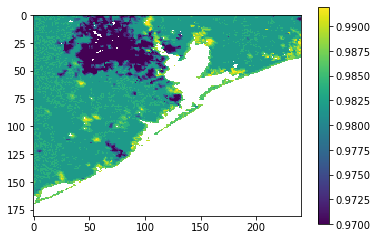

In [97]:
plt.imshow(scaleb1)
plt.colorbar()

In [66]:
%%bash
gdalinfo /shared_space/Galveston_Bay/MODIS_files/MYD11A1.061_Emis_31_doy2020032000000_aid0001.tif

Driver: GTiff/GeoTIFF
Files: /shared_space/Galveston_Bay/MODIS_files/MYD11A1.061_Emis_31_doy2020032000000_aid0001.tif
Size is 241, 181
Coordinate System is:
GEOGCS["WGS 84",
    DATUM["WGS_1984",
        SPHEROID["WGS 84",6378137,298.257223563,
            AUTHORITY["EPSG","7030"]],
        AUTHORITY["EPSG","6326"]],
    PRIMEM["Greenwich",0],
    UNIT["degree",0.0174532925199433],
    AUTHORITY["EPSG","4326"]]
Origin = (-96.008333324732405,30.008333330645030)
Pixel Size = (0.008333333332587,-0.008333333332587)
Metadata:
  add_offset=0.49
  AREA_OR_POINT=Area
  scale_factor=0.002
  units=NA
Image Structure Metadata:
  COMPRESSION=LZW
  INTERLEAVE=BAND
Corner Coordinates:
Upper Left  ( -96.0083333,  30.0083333) ( 96d 0'30.00"W, 30d 0'30.00"N)
Lower Left  ( -96.0083333,  28.5000000) ( 96d 0'30.00"W, 28d30' 0.00"N)
Upper Right ( -94.0000000,  30.0083333) ( 94d 0' 0.00"W, 30d 0'30.00"N)
Lower Right ( -94.0000000,  28.5000000) ( 94d 0' 0.00"W, 28d30' 0.00"N)
Center      ( -95.0041667,  29.2

pj_obj_create: Open of /opt/conda/share/proj failed
